In [1]:
!pip install ultralytics matplotlib opencv-python numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.2 MB/s eta 0:00:00


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
def score_cam(model, image_path, target_class=None):
    """
    Applies Score-CAM to a given image and model to generate a heatmap.

    Args:
        model (YOLO): The trained YOLO model.
        image_path (str): Path to the input image.
        target_class (int, optional): Class ID to focus on, defaults to None.
    
    Returns:
        heatmap (numpy.ndarray): The generated heatmap.
    """
    # Move model to the same device as the input
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)

    # Load the image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

    # Preprocess the image for YOLO input
    img_resized = cv2.resize(img_rgb, (640, 640))  # Resize to YOLO input size
    img_normalized = img_resized / 255.0  # Normalize pixel values
    img_tensor = torch.tensor(img_normalized).float().permute(2, 0, 1).unsqueeze(0)  # Convert to tensor

    # Move the tensor to the same device as the model
    img_tensor = img_tensor.to(device)

    # Perform inference
    with torch.no_grad():
        results = model(img_tensor)

    # Extract predictions from the results
    pred = results[0]  # First prediction in the results

    # If no detections are found, skip this image
    if len(pred.boxes) == 0:
        print(f"No detections in {image_path}")
        return None

    # Get the predicted class IDs (based on highest confidence score for each box)
    pred_class_ids = pred.boxes.cls.cpu().numpy().astype(int)  # Class IDs of detected objects
    pred_scores = pred.boxes.conf.cpu().numpy()  # Confidence scores for the detections

    # If target_class is not specified, use the class with the highest confidence
    if target_class is None:
        target_class = pred_class_ids[np.argmax(pred_scores)]  # Default to the most confident detection class

    # Obtain activations from the model's intermediate layers (change based on your model architecture)
    activations = model.model.model[0](img_tensor)  # Access intermediate layers in YOLO (change index as needed)

    # Extract the feature map after passing through the convolutional layers (e.g., after the first layer)
    # Ensure activations have a 3D shape: (channels, height, width)
    activations = activations.detach().cpu().numpy()

    # Score-CAM heatmap generation logic
    weights = np.mean(activations, axis=(1, 2))  # Averaging across spatial dimensions
    weighted_activation = np.zeros_like(activations[0])  # Initialize the weighted activation map

    for i, w in enumerate(weights):
        weighted_activation += w * activations[i]

    # Normalize the heatmap (convert to 2D)
    heatmap = cv2.resize(weighted_activation, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.maximum(heatmap, 0)  # Ensure all values are positive
    heatmap = heatmap / np.max(heatmap)  # Normalize to [0, 1]

    # Ensure heatmap is 2D and of the correct type (uint8)
    heatmap_img = np.uint8(255 * heatmap)  # Convert to 0-255 range for OpenCV (CV_8UC1)

    # Apply colormap (ensure the input is 2D and single-channel)
    if len(heatmap_img.shape) == 2:  # Check if it's 2D
        heatmap_colored = cv2.applyColorMap(heatmap_img, cv2.COLORMAP_JET)
    else:
        raise ValueError("The heatmap image is not in the expected 2D format.")

    # Overlay heatmap on the original image
    superimposed_img = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

    # Display the result
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

    return heatmap

In [4]:
def score_cam(model, image_path, target_class=None):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img_resized = cv2.resize(img_rgb, (640, 640))
    img_normalized = img_resized / 255.0
    img_tensor = torch.tensor(img_normalized).float().permute(2, 0, 1).unsqueeze(0).to(device)

    results = model(img_tensor)
    pred = results[0]

    if len(pred.boxes) == 0:
        print(f"No detections in {image_path}")
        return None

    # ইন্টারমিডিয়েট লেয়ার থেকে আউটপুট নেওয়া
    # এখানে .detach().cpu().numpy()[0] ব্যবহার করে ব্যাচ ডাইমেনশন (১ম ডাইমেনশন) বাদ দেওয়া হয়েছে
    activations = model.model.model[0](img_tensor).detach().cpu().numpy()[0] 
    
    channels, h, w = activations.shape

    # Score-CAM ওয়েট ক্যালকুলেশন (Global Average Pooling এর মতো)
    weights = np.mean(activations, axis=(1, 2)) 
    
    # ওয়েটেড অ্যাক্টিভেশন ম্যাপ তৈরি
    weighted_activation = np.zeros((h, w), dtype=np.float32)
    for i, w in enumerate(weights):
        weighted_activation += w * activations[i]

    # রিলু (ReLU) প্রয়োগ এবং নরমালাইজেশন
    heatmap = np.maximum(weighted_activation, 0)
    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    # ইমেজ সাইজে রিসাইজ করা
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_img = np.uint8(255 * heatmap_resized)

    # কালার ম্যাপ অ্যাপ্লাই করা (এখন এটি নিশ্চিতভাবেই 2D)
    heatmap_colored = cv2.applyColorMap(heatmap_img, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # ওভারলে করা
    superimposed_img = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(f"Target Class: {target_class if target_class else 'Auto'}")
    plt.show()

    return heatmap

In [5]:
# Load the YOLO model
model = YOLO("/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/best.pt")

In [6]:
# Image paths
image_paths = [
    "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/115_jpg.rf.e502e3b728f83a17a782892ab3edae06.jpg",
    "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/119_jpg.rf.ad17e6675f1796e0ac9dd0803fa6a2d7.jpg",
    "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/11_jpg.rf.029e4ec17b946a6ff57332f489f2d6f4.jpg"
]


0: 640x640 8 Fractured Teeths, 62.6ms
Speed: 0.1ms preprocess, 62.6ms inference, 53.8ms postprocess per image at shape (1, 3, 640, 640)


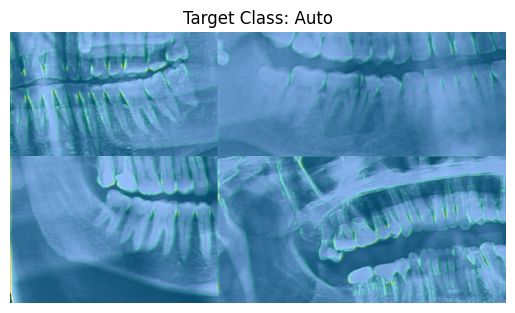


0: 640x640 1 Healthy Teeth, 2 Impacted Teeths, 6 Fractured Teeths, 59.3ms
Speed: 0.0ms preprocess, 59.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


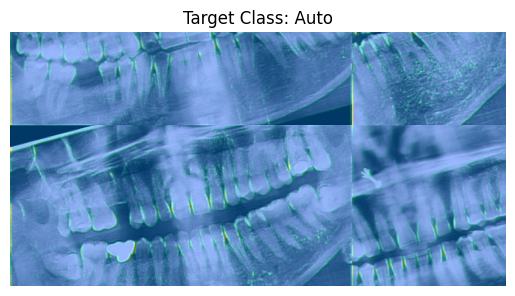


0: 640x640 2 Healthy Teeths, 3 Impacted Teeths, 7 Fractured Teeths, 47.6ms
Speed: 0.0ms preprocess, 47.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


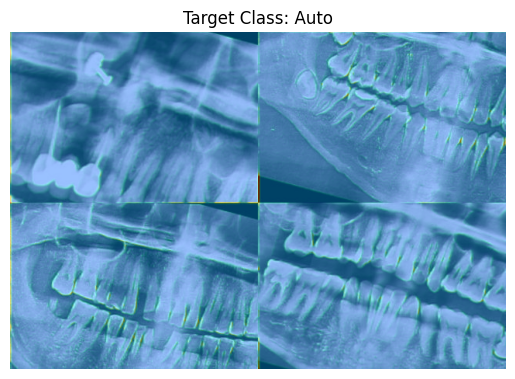

In [7]:
# Apply Score-CAM to each image
for image_path in image_paths:
    score_cam(model, image_path)